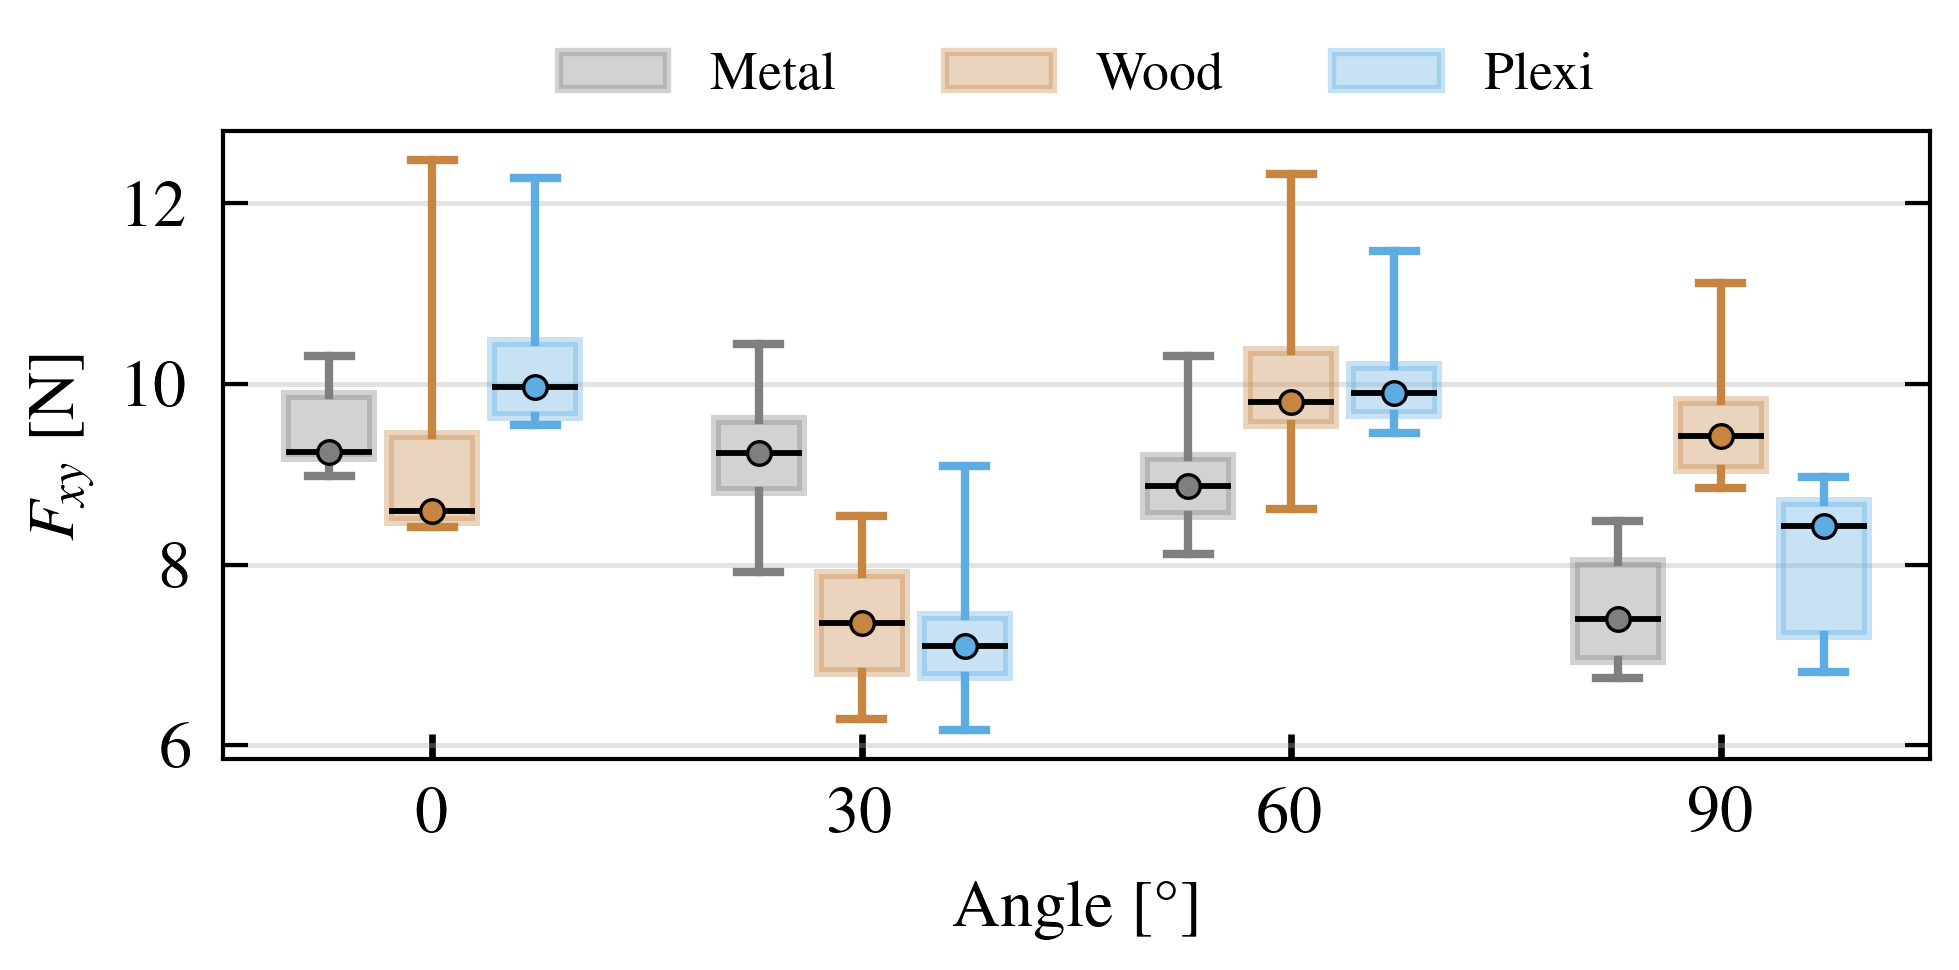

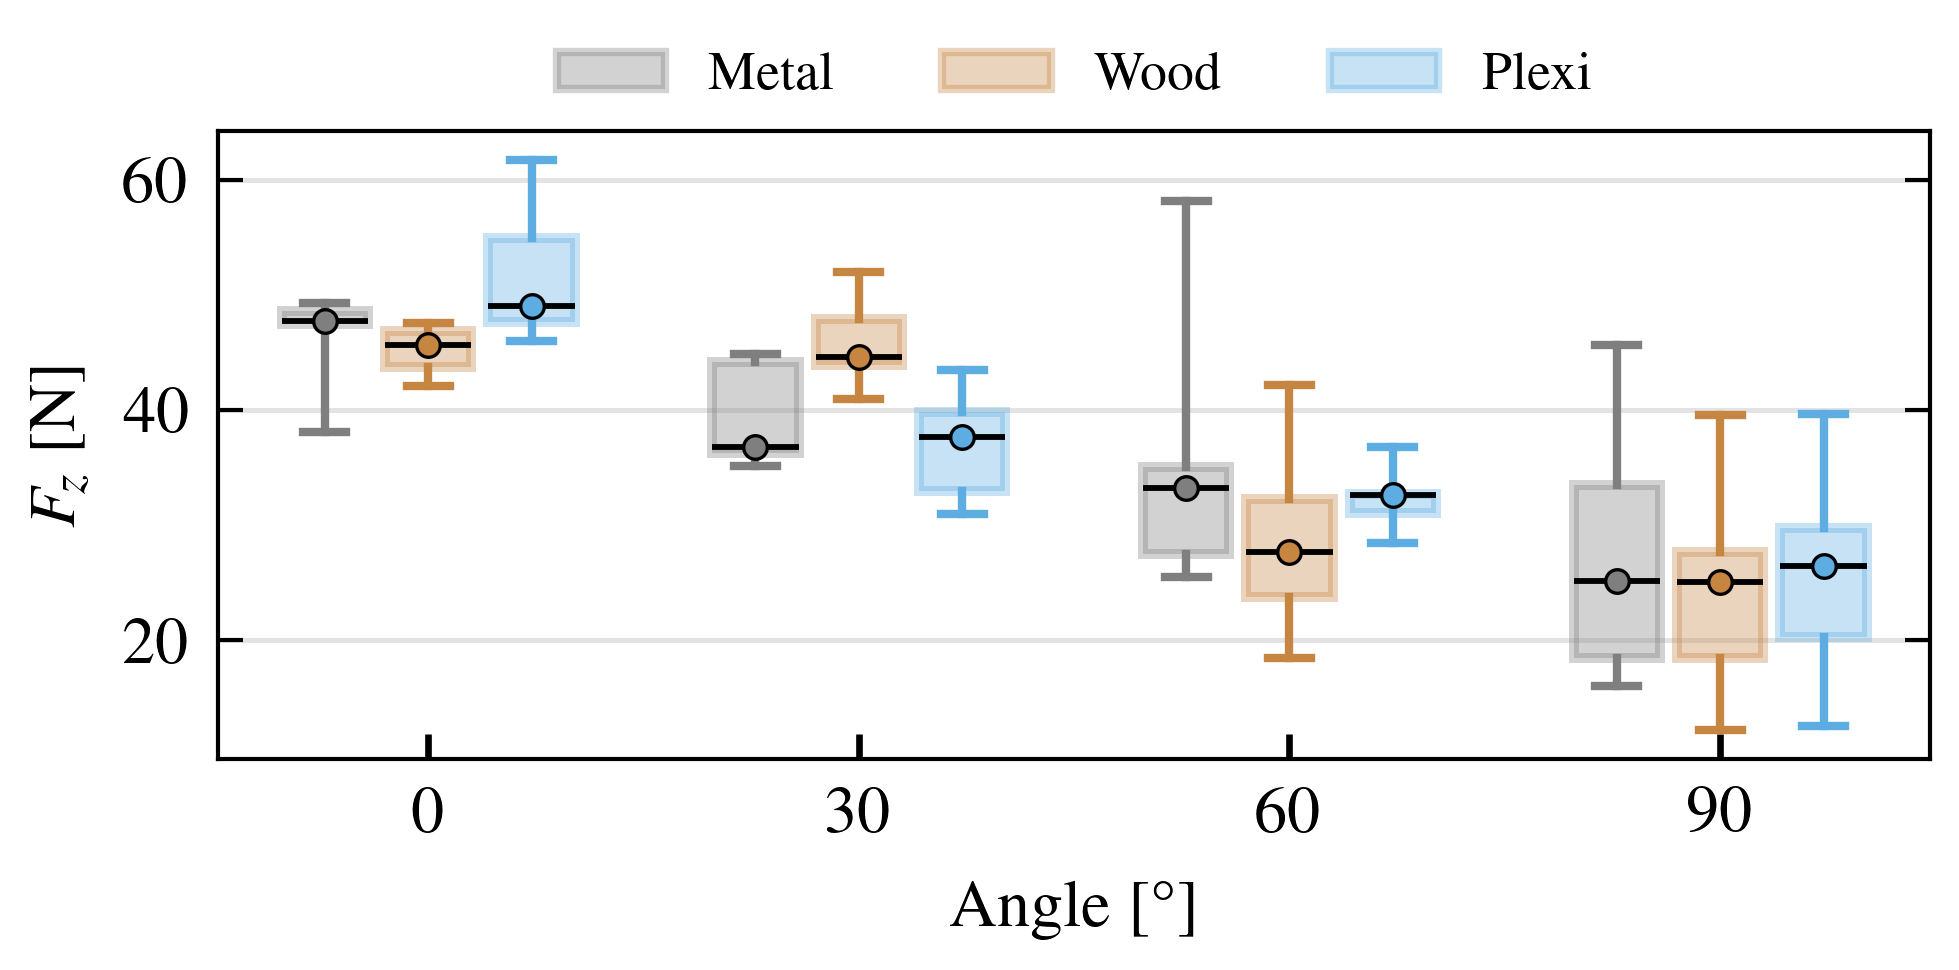

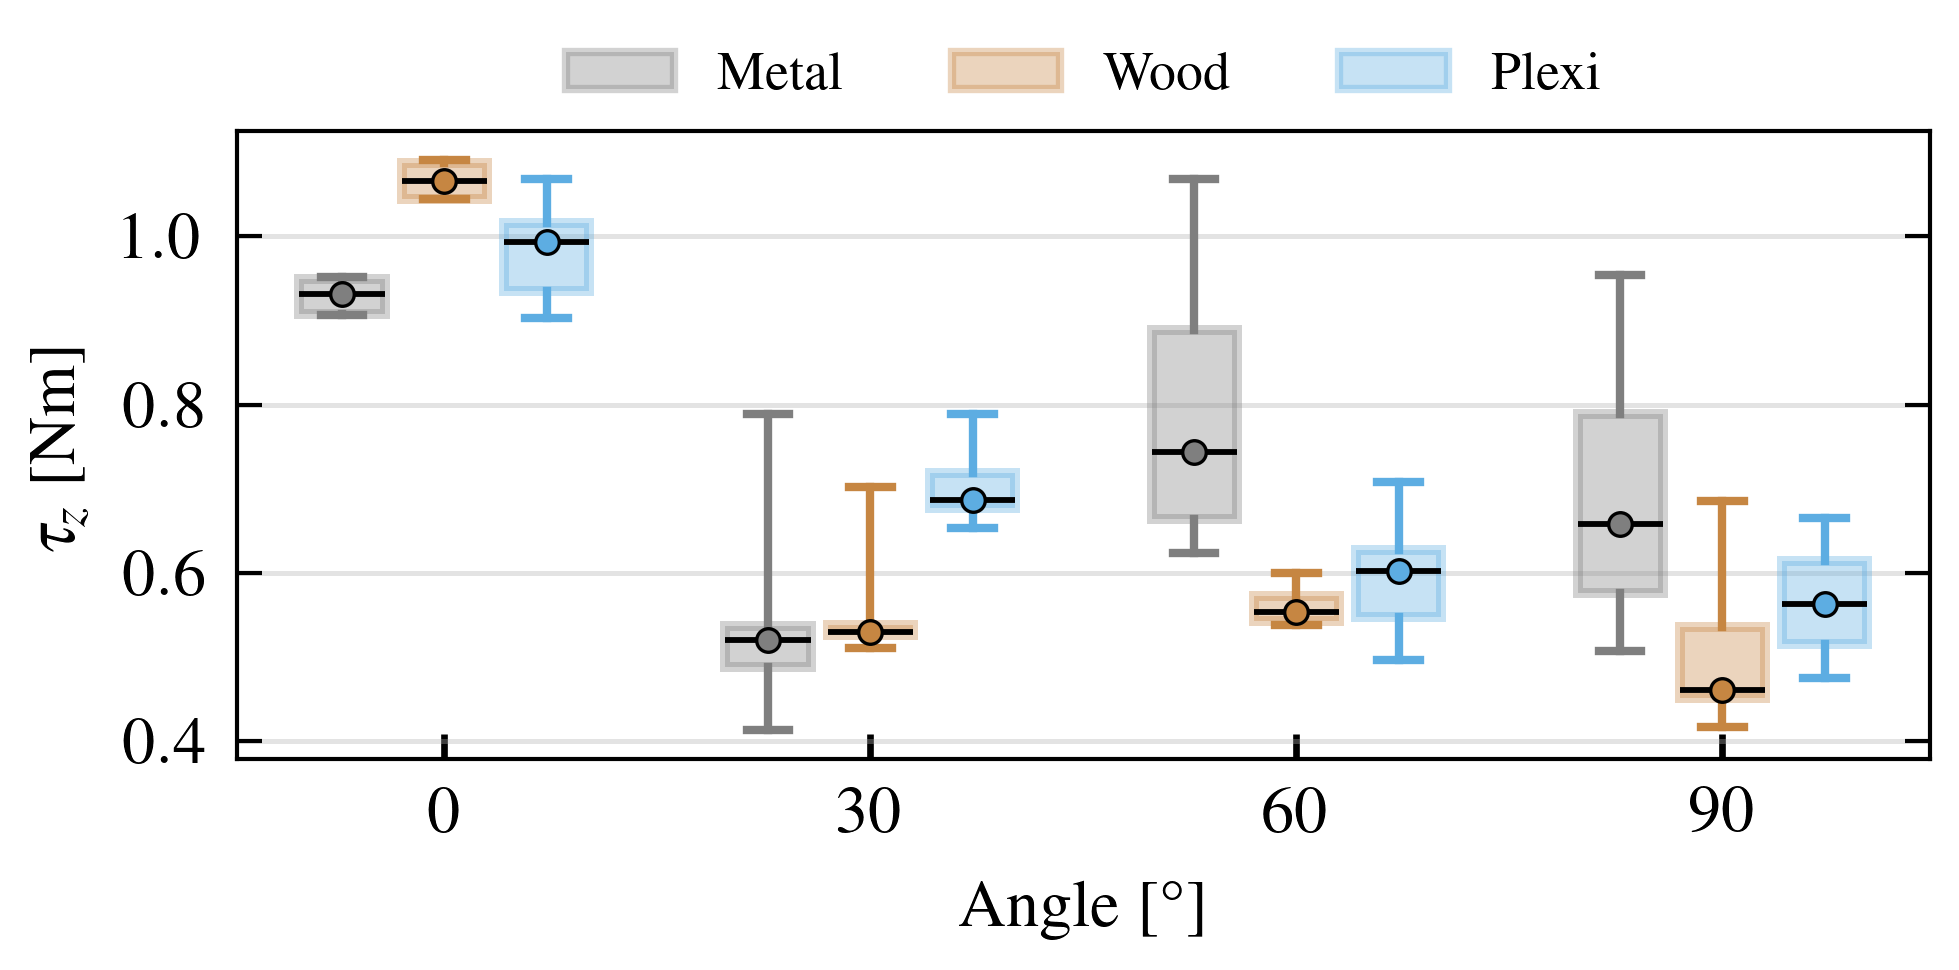

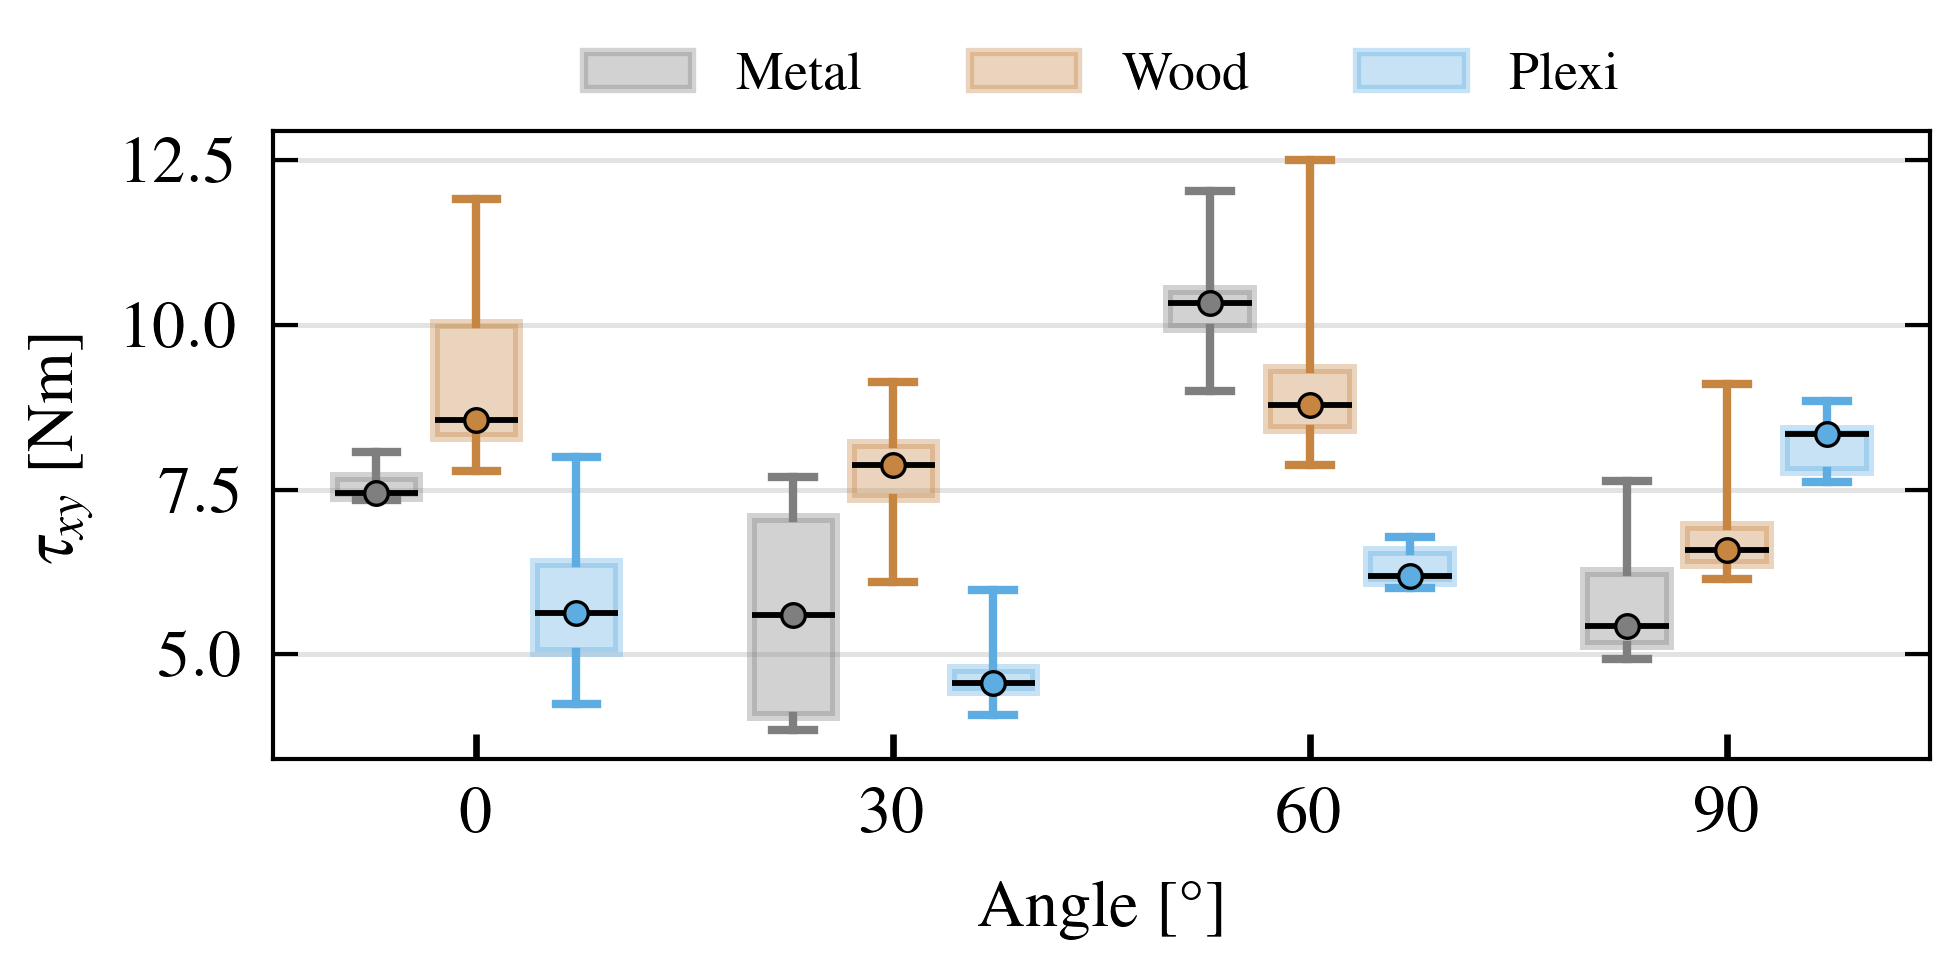

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scienceplots

plt.style.use(["science", "ieee"])

CSV_FILE = "gripper_break_results_summary_copy.csv"

METHOD_ORDER = ["xy", "z", "yaw", "roll_pitch"]
SURFACE_ORDER = ["Metal", "Wood", "Plexi"]

SURFACE_COLORS = {
    "Metal": "#7f7f7f",
    "Wood": "#c68642",
    "Plexi": "#5dade2",
}

FIGSIZE_IN = (3.25, 1.4)

ylabel_map = {
    "xy": r"$F_{xy}$ [N]",
    "z": r"$F_z$ [N]",
    "yaw": r"$\tau_{z}$ [Nm]",
    "roll_pitch": r"$\tau_{xy}$ [Nm]",
}

# read csv
df = pd.read_csv(CSV_FILE)
df.columns = [c.strip() for c in df.columns]

# numeric conversion
numeric_cols = ["angle", "n", "mean", "std", "median", "q1", "q3", "min", "max", "iqr"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# only peak_signal
df = df[df["variable"] == "peak_signal"].copy()

# drop rows with missing key values
df = df.dropna(subset=["method", "surface", "angle", "median", "q1", "q3", "min", "max"])
for method in METHOD_ORDER:
    df_method = df[df["method"] == method].copy()
    if df_method.empty:
        continue

    df_method = df_method.drop_duplicates(subset=["angle", "surface"], keep="first")

    angles_used = sorted(df_method["angle"].dropna().unique())
    surfaces_used = [s for s in SURFACE_ORDER if s in df_method["surface"].unique()]

    if len(angles_used) == 0 or len(surfaces_used) == 0:
        continue

    fig, ax = plt.subplots(figsize=(3.25, 1.6), constrained_layout=True)

    x_centers = list(range(len(angles_used)))

    n_surfaces = len(surfaces_used)
    group_width = 0.72
    box_width = 0.20

    legend_handles = []

    for s_idx, surface in enumerate(surfaces_used):
        color = SURFACE_COLORS.get(surface, "lightgray")
        stats = []
        positions = []
        medians_y = []

        offset = (s_idx - (n_surfaces - 1) / 2.0) * (group_width / max(n_surfaces, 1))

        for i, angle in enumerate(angles_used):
            row = df_method[
                (df_method["surface"] == surface) &
                (df_method["angle"] == angle)
            ]

            if row.empty:
                continue

            row = row.iloc[0]
            pos = x_centers[i] + offset

            stats.append({
                "whislo": row["min"],
                "q1": row["q1"],
                "med": row["median"],
                "q3": row["q3"],
                "whishi": row["max"],
                "fliers": [],
            })
            positions.append(pos)
            medians_y.append(row["median"])

        if not stats:
            continue

        bplot = ax.bxp(
            stats,
            positions=positions,
            widths=box_width,
            showfliers=False,
            patch_artist=True,
            manage_ticks=False
        )

        # boxes
        for patch in bplot["boxes"]:
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(0.35)
            patch.set_linewidth(1.2)

        # whiskers and caps
        for whisker in bplot["whiskers"]:
            whisker.set_color(color)
            whisker.set_linewidth(1.0)

        for cap in bplot["caps"]:
            cap.set_color(color)
            cap.set_linewidth(1.0)

        # median
        for median in bplot["medians"]:
            median.set_color("black")
            median.set_linewidth(0.7)

        # add median marker so collapsed boxes remain visible
        ax.scatter(
            positions,
            medians_y,
            s=8,
            color=color,
            edgecolors="black",
            linewidths=0.4,
            zorder=4
        )

        legend_handles.append(
            Patch(facecolor=color, edgecolor=color, alpha=0.35, label=surface)
        )

    ax.set_xticks(x_centers)
    ax.set_xticklabels([str(int(a)) if float(a).is_integer() else str(a) for a in angles_used])

    ax.tick_params(axis="x", which="major", bottom=True, top=False, length=3, width=0.8)
    ax.tick_params(axis="x", which="minor", bottom=False, top=False)
    ax.minorticks_off()

    ax.set_xlabel("Angle [°]")
    ax.set_ylabel(ylabel_map.get(method, "Value"))

    # cleaner look
    ax.grid(True, axis="y", alpha=0.35, linewidth=0.6)
    ax.grid(False, axis="x")

    #ax.spines["top"].set_visible(False)
    #ax.spines["right"].set_visible(False)

    ax.margins(x=0.04)

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            ncol=len(legend_handles),
            loc="lower center",
            bbox_to_anchor=(0.5, 0.97),
            frameon=False,
            fontsize=6.5
        )

    plt.show()
    plt.close(fig)

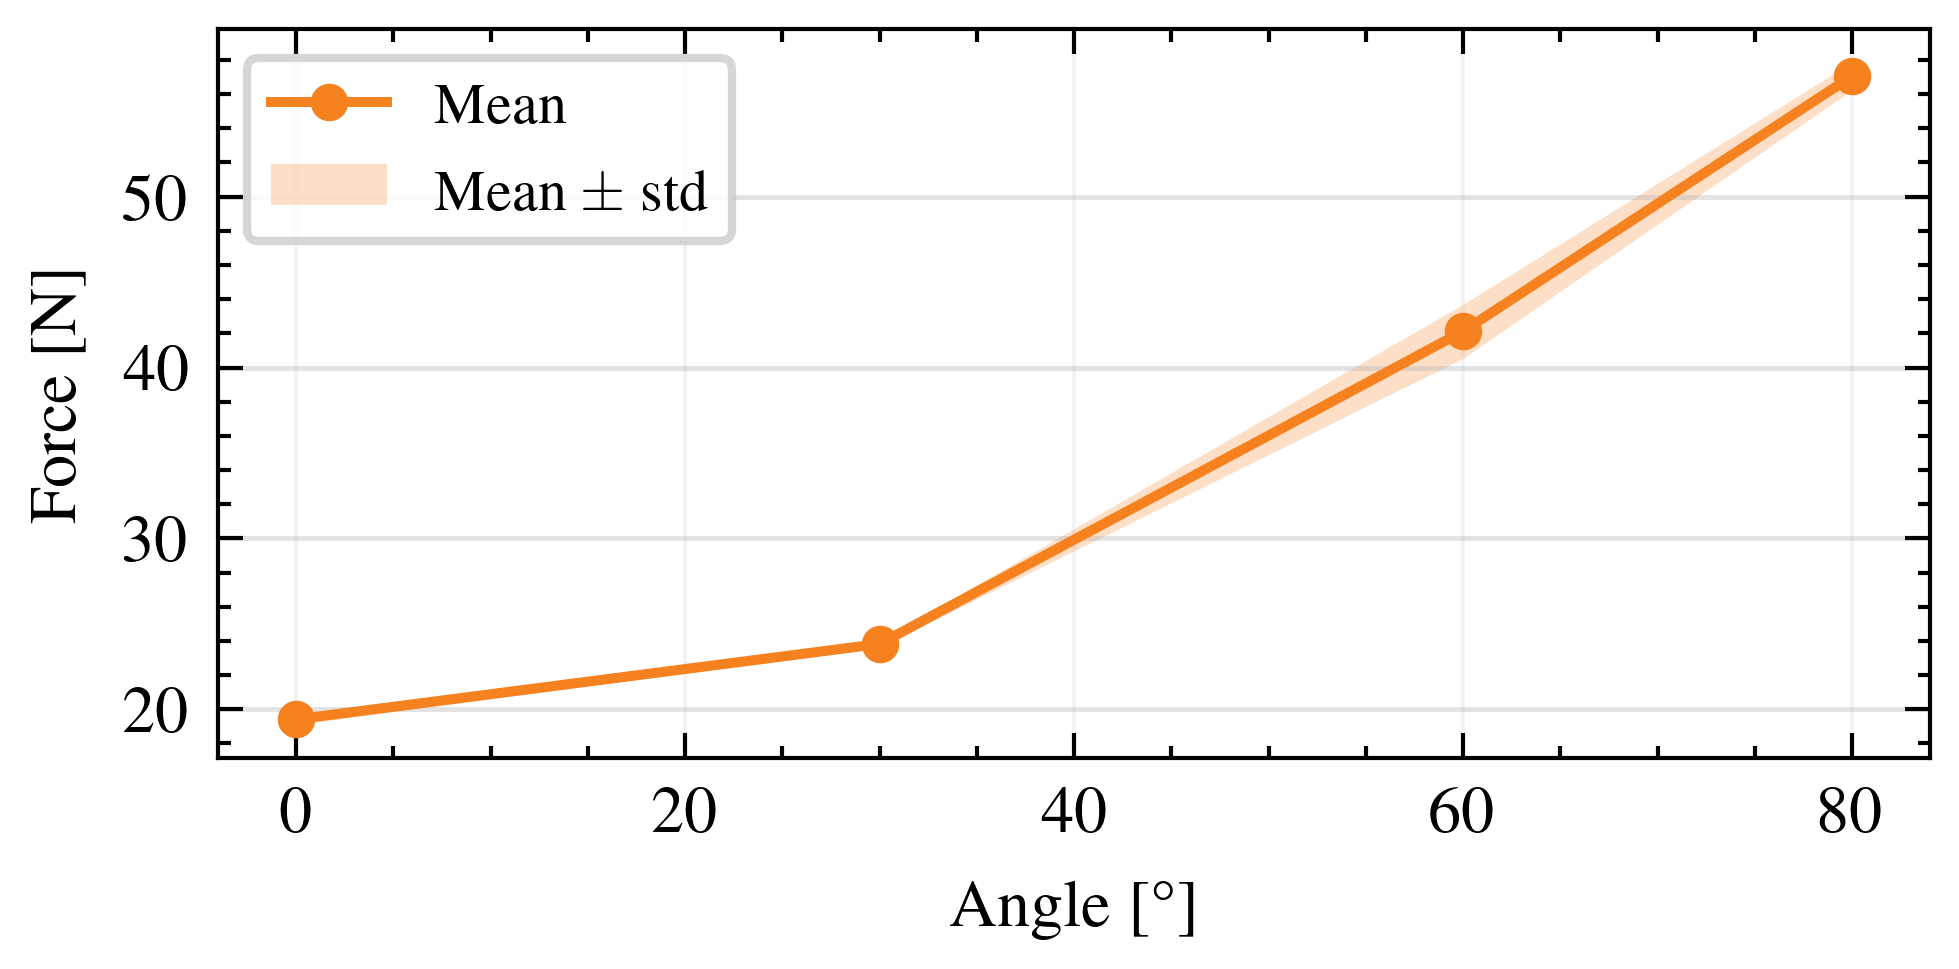

In [10]:
CSV_FILE = "missaligned_summary.csv"
FIGSIZE_IN = (3.25, 1.6)

# read csv
df = pd.read_csv(CSV_FILE)
df.columns = [c.strip() for c in df.columns]

# numeric conversion
numeric_cols = ["angle", "n", "mean", "std", "median", "q1", "q3", "min", "max", "iqr"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# keep only peak_signal
df = df[df["variable"] == "peak_signal"].copy()

# drop incomplete rows
df = df.dropna(subset=["angle", "mean", "std"])

# if duplicates exist for same angle, keep first
df = df.drop_duplicates(subset=["angle"], keep="first")

# sort by angle
df = df.sort_values("angle")

x = df["angle"].to_numpy()
y = df["mean"].to_numpy()
y_std = df["std"].to_numpy()

fig, ax = plt.subplots(figsize=FIGSIZE_IN, dpi=600, constrained_layout=True)

ax.plot(
    x,
    y,
    marker="o",
    linewidth=1.2,
    markersize=3.5,
    color="#F5821F",
    label="Mean"
)

ax.fill_between(
    x,
    y - y_std,
    y + y_std,
    color="#F5821F",
    alpha=0.25,
    linewidth=0,
    label=r"Mean $\pm$ std"
)

ax.set_xlabel("Angle [°]")
ax.set_ylabel("Force [N]")

ax.grid(True, axis="y", alpha=0.35, linewidth=0.6)
ax.grid(True, axis="x", alpha=0.15, linewidth=0.5)

ax.legend(frameon=True, fontsize=7)

plt.show()
plt.close(fig)